# LIVRABLE - PARTIE 0 : IMPORTATION ET ALIMENTATION DES TABLES DE LA BASE DE DONNEES OlistCommerce

**Projet :** Base de données OlistCommerce  
**SGBD :** Microsoft SQL Server  
**Auteur :** Masuku Henri

---

## 1. Méthodologie et stratégie d'importation des données 

### 1.1 Principe général (Méthode en 4 Étapes)
Pour charger l'ensemble des données CSV du projet OlistCommerce dans SQL Server sans rencontrer d'erreurs de format, de type ou d'encodage, nous avons mis en place un processus d'ingestion robuste basé sur une **zone de transit (Staging Area)**.

```text
[ Fichier CSV ] ──(BULK INSERT)──> [ Table Staging (_staging) ] ──(Nettoyage & Conversion)──> [ Table Finale Cible ]
```

1. **Création d'une table de staging (`dbo.<nom_table>_staging`)** :
   Une table temporaire est créée dans laquelle toutes les colonnes sont définies en texte libre (`VARCHAR(MAX)` ou `NVARCHAR(MAX)`). Cela garantit qu'aucun rejet de ligne ne survienne lors du premier chargement.  

2. **Importation brute (`BULK INSERT`)** :
   Le fichier CSV est chargé directement dans la table de staging. Les paramètres clés utilisés sont :
   * `FORMAT = 'CSV'` et `FIELDQUOTE = '"'` : gère correctement les champs texte contenant des virgules ou des retours à la ligne.
   * `CODEPAGE = '65001'` : prend en compte l'encodage **UTF-8** pour conserver les caractères spéciaux et accents (ex: portugais).
   * `FIRSTROW = 2` : ignore la première ligne contenant les en-têtes.
   * `ROWTERMINATOR = '0x0d0a'` : définit le saut de ligne au format Windows (`\r\n`).  

3. **Nettoyage et transfert vers la table finale (`INSERT INTO ... SELECT`)** :
   * **Suppression des espaces inutiles** via `TRIM()`.
   * **Gestion des valeurs vides** : conversion des chaînes vides `''` en `NULL` avec `NULLIF()`.
   * **Normalisation des nombres** : remplacement des virgules décimales `,` par des points `.` via `REPLACE()`.
   * **Conversion sécurisée** vers les types finaux (`INT`, `FLOAT`, `DECIMAL`, `DATETIME2`, `VARCHAR`) grâce à `TRY_CAST()`, évitant ainsi le blocage complet du script en cas d'anomalie.  

4. **Nettoyage (`DROP TABLE`)** :  
   Suppression de la table temporaire de staging une fois l'insertion réussie.

---

### 1.2 Ordre d'exécution (Respect des clefs étrangères)
Afin de respecter la cohérence des données et éviter les blocages dus aux contraintes de clés étrangères (relations entre les tables), les tables sont importées selon un ordre strict :

|  | Table | Dépendances / Clés Étrangères | Rôle de la Table |
| :---: | :--- | :--- | :--- |
| **1** | `customers` | Aucune | Liste des clients |
| **2** | `sellers` | Aucune | Liste des vendeurs |
| **3** | `products` | Aucune (dans notre schéma) | Catalogue des produits |
| **4** | `product_category_name_translation` | Aucune | Traduction des catégories |
| **5** | `orders` | Dépend de `customers(customer_id)` | Commandes passées |
| **6** | `order_items` | Dépend de `orders`, `products`, `sellers` | Articles contenus dans chaque commande |
| **7** | `order_payments` | Dépend de `orders(order_id)` | Modes de paiement des commandes |
| **8** | `order_reviews` | Dépend de `orders(order_id)` | Avis et évaluations des clients |

---

## 2. Procédure d'importation des tables

### a). Tables racines
Les tables racines sont celles qui ne dépendent d'aucune autre table pour leur création.  
Elles sont importées en premier.

Les scripts d'importation se trouvent dans le dossier `bulk_inserts/` et suivent la convention de nommage suivante :

`bulk_inserts/olistDB_nom_de_la_table_bulkInsert.sql`

**Exemple :**  
Pour importer la table `products`, utilisez le fichier :  
`bulk_inserts/olistDB_products_bulkInsert.sql`



### b). Tables dépendantes
Les tables dépendantes nécessitent que les tables racines soient déjà créées et remplies, car elles font référence à des clés étrangères.

Les scripts d'importation suivent la même convention de nommage :

`bulk_inserts/olistDB_nom_de_la_table_bulkInsert.sql`

**Exemple :**  
Pour importer la table `order_reviews`, utilisez le fichier :  
`bulk_inserts/olistDB_order_reviews_bulkInsert.sql`

---

**NOTE IMPORTANTE : Ordre d'importation**  
1. Importer toutes les tables racines.  
2. Importer ensuite les tables dépendantes dans l'ordre respectant les contraintes de clés étrangères.

**Remarque :** Le préfixe `olistDB_` est systématiquement utilisé pour tous fichiers d'importation correspondants.

---

## 3. Script de vérification des importations (Exercice 0.4)

Afin de vérifier que **100 % des enregistrements** ont été correctement importés sans aucune perte de données, exécutez les scripts suivants dans SQL Server Management Studio (SSMS) pu tout autre outil dédié .

###  Vérification par comptage (`COUNT(*)`)  

Après l'importation des données, la requête de vérification ci-dessous permet de compter le nombre d'enregistrements dans chaque table.

### Objectif
- Vérifier que toutes les tables ont bien été importées
- Identifier rapidement d'éventuelles anomalies (table vide ou nombre inattendu)

In [ ]:
USE OlistCommerce;
GO

SELECT 'customers' AS nom_table, COUNT(*) AS nombre_entrees FROM customers
UNION ALL
SELECT 'sellers', COUNT(*) FROM sellers
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'product_category_name_translation', COUNT(*) FROM product_category_name_translation
UNION ALL
SELECT 'orders', COUNT(*) FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'order_payments', COUNT(*) FROM order_payments
UNION ALL
SELECT 'order_reviews', COUNT(*) FROM order_reviews
ORDER BY nombre_entrees DESC;

>## Capture d'écran de vérification des imports

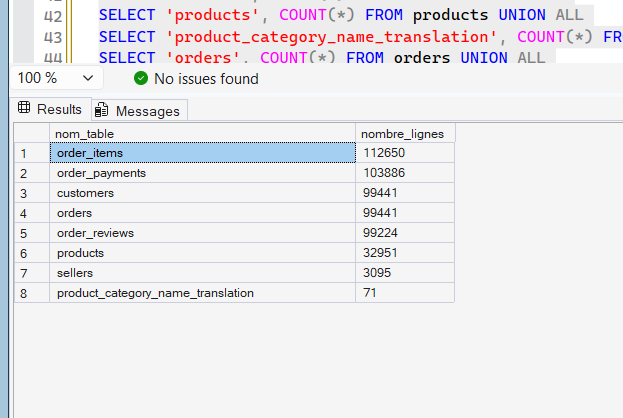


---

## 4. Journal de Bord (Incidents rencontrés & solutions )

Le tableau ci-dessous récapitule les principales difficultés techniques rencontrées lors de l'importation ainsi que les solutions apportées :

| # | Problème / Symptôme | Cause Racine | Solution Technique Appliquée |
| :-: | :--- | :--- | :--- |
| **1** | **Doublons de clés primaires sur `order_reviews`** | Le champ `review_id` présentait 814 valeurs dupliquées (un même avis laissé pour une commande groupée). | **Résolution :** Définition d'une **clé primaire composée** `(review_id, order_id)`. **Résultat :** 100 % des 99 224 lignes ont été conservées sans perte. |
| **2** | **Erreur `Msg 2628` (Troncation de texte ou de chaîne)** | Certains commentaires clients (`review_comment_message`) contenaient des retours à la ligne (`\n`) ou des textes longs. | Passage systématique par une table de **Staging** en `NVARCHAR(MAX)` et utilisation de `FIELDQUOTE = '"'` dans l'instruction `BULK INSERT`. |
| **3** | **Problèmes d'affichage des caractères accentués** *(ex: São Paulo)* | L'encodage par défaut de SQL Server ne gérait pas correctement les caractères d'origine du CSV. | Ajout de la propriété **`CODEPAGE = '65001'` (UTF-8)** dans la commande `BULK INSERT`. |
| **4** | **Erreurs de conversion sur les dates et montants** | Présence de chaînes vides `''` ou de virgules décimales `,` dans les champs numériques/dates. | Combinaison systématique de `TRIM()`, `NULLIF(col, '')`, `REPLACE(col, ',', '.')` et `TRY_CAST()` pour convertir en toute sécurité vers `NULL` sans bloquer le traitement. |
| **5** | **Conflits de contraintes de Clés Étrangères (`FOREIGN KEY`)** | Tentative d'insertion d'enregistrements dans une table fille avant que la table parent ne soit remplie. | Établissement d'un **ordre strict d'exécution** en chargeant d'abord les tables indépendantes (Dimensions) avant les tables dépendantes (Faits). |